# Flash Drought Detection

In this notebook, we will apply the technique we learned in the previous part to a new case study in South Africa in 2024 and determine its predictive skill as an early warning of drought. In particular, we will apply a "detection rule" to the time series of SIF-RCI and SWDI to see when our data would indicate a developing flash drought. The "detection rule" is based on two primary values:

* The **drought severity**: a threshold value below which we declare a drought
* The **speed of drought development**: the length of time that an indicator changes from normal/mild to severe anomaly is a distinguishing factor for flash drought

In research, these values are chosen based on maximizing the predictive skill of the rules compared to an established catalog of flash drought \[[3](https://doi.org/10.1073/pnas.2202767119)\]\[[4](https://doi.org/10.1175/BAMS-D-24-0143.1)\]\[[14](https://doi.org/10.1016/j.jhydrol.2014.12.051)\]\[[17](https://doi.org/10.5194/hess-25-565-2021)\]. For our purposes, the values can be changed subjectively, but the approach should still be informed by similar work. 

### The 2023/2024 Summer Flash Drought in South Africa

The case study for this notebook is a flash drought that occurred in South Africa during the 2023-2024 growing season (remember, December to March is summer in the Southern Hemisphere) and is discussed in detail in Malherbe et al., 2025 \[[15](https://doi.org/10.1016/j.envdev.2025.101253)\]. Although this analysis will focus on South Africa and a small portion of Lesotho, the flash drought affected a larger area across much of Southern Africa including as far north as Angola and Zambia.

Source for South African crop calendar dates: https://sagrainmag.co.za/2022/11/04/when-is-it-too-late-to-plant/

This article has information based on this study:

Moeletsi, ME. (2017). Mapping of Maize Growing Period over the Free State Province of South Africa: Heat Units Approach. 
Advances in Meteorology, 2017, 1 - 11. https://doi.org/10.1155/2017/7164068

As the study is quite complicated for the rough estimates we are trying to get, the key takeaway is that most maize in the eastern part of Free State
grows in about 140-160 days, giving us a harvest period from early April to mid-May. 

In the first three cells below, we will repeat the process that was covered in the first notebook:
* Retrieve the necessary GOSIF data. As with the Great Plains case study, climatology for this region has already been processed and is located in the `inputs` directory.
* Compute time series of SIF-RCI and SWDI, saving the results as CSV. A key difference here from the previous notebook is that we will also save a geotiff of each time step of SIF-RCI and SWDI to preserve the spatial variations in these indicators for later. We also compute the **SIF Z-Score** in addition to SIF Standardized Anomaly from before. Unlike Standardized anomaly that was examined in Part I, this Z-score tells us the anomaly in the SIF values at the jth time window, rather than the anomaly in the difference between time steps. The SIF Z-Score provides more diagnostic information about the antecedent conditions of SIF as we will see.
* Plot the time series in a single figure. Instead of plotting SIF Standardized Anomaly, we will plot the Z-Score we calculated. 

In [1]:
"""Inputs
In this case study, we will use a portion of Free State in South Africa as a region of interest, but this notebook
is set up to make it easier for you to input your own region of interest and date range. Along with modifying the input values
in this cell, you will want to run the Appendix notebook with updated values.

Directions for using your own region:
1. Using GIS software or Google Maps, determine the coordinates of a region of interest. Currently, only rectangular regions are supported.
2. Go to the Appendix notebook (3_appendix.ipynb), run the first code cell, then follow the instructions in the second code cell.
3. Find the crop calendar for the primary crop(s) in your region of interest. This will require your own research or prior knowledge, but it is
  very important to determine if a flash drought signal is agriculturally impactful.
4. Set the following variables in this cell:
  a. region_name, plot_region_name (str): Any name you want. region_name will be used in the filenames, plot_region_name will be used in the plot title.
  b. west, south, east, north (four floats): The coordinates of the region of interest.
  c. date_range (list[datetime]): The start and end dates of the time period you want to analyze.
  d. planting_start, planting_end, harvest_start, harvest_end (four datetimes): The crop calendar dates for the region.
  e. plot_title (str): Title to be used in the plot in the fourth cell.
"""
from datetime import datetime, timedelta

# Free State South Africa region of interest
region_name = "south_africa"
plot_region_name = "Free State South Africa"
# 28.00°-29.00°S, 27.00°-28.50°E
west, south, east, north = 27.0, -29.0, 28.5, -28.0

# For the South Africa case study, we will download data from September 2023 (just before the spring planting) through to
# August 2024 (after the harvest)
date_range = [datetime(2023, 9, 1), datetime(2024, 8, 31)] # noqa: DTZ001
start, end = date_range

# Typical crop calendar for Maize (Corn) in Free State South Africa:
#   Planting: October 20 - December 10 (late October to early December)
#   Harvest:  April 1 - May 15
planting_start, planting_end = datetime(start.year, 10, 20), datetime(start.year, 12, 10) # noqa: DTZ001
harvest_start, harvest_end = datetime(end.year, 4, 1), datetime(end.year, 5, 15) # noqa: DTZ001

years = sorted({str(dt.year) for dt in date_range})
year_str = '_'.join(years)
plot_year_str = '-'.join(years)

def format_coords(coord_left: float, coord_right: float, is_lat: bool = True) -> str:
    if is_lat:
        hem_left  = "N" if coord_left > 0.0 else "S"
        hem_right = "N" if coord_right > 0.0 else "S"
    else:
        hem_left  = "E" if coord_left > 0.0 else "W"
        hem_right = "E" if coord_right > 0.0 else "W"
    hem_left = "" if hem_right == hem_left else hem_left
    return f"{abs(coord_left)}°{hem_left}-{abs(coord_right)}°{hem_right}"

plot_title = f"SIF-RCI over {plot_region_name} ({plot_year_str})\n{format_coords(north, south)}, {format_coords(west, east, is_lat=False)}"
plot2_title = f"SIF-RCI with Flash Drought Detections over {plot_region_name} ({plot_year_str})\n{format_coords(north, south)}, {format_coords(west, east, is_lat=False)}"

def doy_to_date(year, doy):
    return datetime(year, 1, 1) + timedelta(days=doy - 1) # noqa: DTZ001

doy_range: list[tuple[int, int]] = []
for year in range(start.year, end.year + 1):
    for doy in range(1, 365, 8):
        d = doy_to_date(year, doy)
        if start <= d <= end:
            doy_range.append((year, doy))

# Set the filename to use for the time series
sif_time_series_fname = f"{region_name}_{year_str}_sif.csv"
swdi_time_series_fname = f"{region_name}_{year_str}_swdi.csv"

# Set the directory to save the rasters for each time step
raster_dir = f"data/{region_name}_time_steps"
fd_dir = f"data/{region_name}_fd"

In [2]:
import os

from download import download_unpack_gosif
from tqdm.notebook import tqdm

output_dir = "data/gosif"
os.makedirs(output_dir, exist_ok=True)

gosif_geotiffs: list[str] = []
for year, doy in tqdm(doy_range, desc="Downloading granules"):
    fname = download_unpack_gosif(
        year,
        day=doy,
        output_dir=output_dir,
        verbose=False
    )
    if fname:
        gosif_geotiffs.append(fname)

In [3]:
from analysis import compute_sif_time_series, compute_swdi_timeseries

# Get the climatology inputs produced by the appendix notebook
clim_dir = f"inputs/sif_increments_{region_name}/"
#clim_dir = "inputs/sif_increments/"

if not os.path.exists(f"data/{sif_time_series_fname}"):
    sif_csv_path, n_dates = compute_sif_time_series(
        gosif_geotiffs,
        clim_dir,
        sif_time_series_fname,
        west, south, east, north,
        raster_dir=raster_dir,
    )
    print(f"SIF: Computed time series values for {n_dates} granules and saved to {sif_csv_path}")
else:
    sif_csv_path = f"data/{sif_time_series_fname}"

if not os.path.exists(f"data/{swdi_time_series_fname}"):
    swdi_csv_path = compute_swdi_timeseries(
        start.strftime("%Y-%m-%d"),
        end.strftime("%Y-%m-%d"),
        swdi_time_series_fname,
        (west, south, east, north),
        raster_dir=raster_dir,
    )
    print(f"SWDI: Saved time series values to {swdi_csv_path}")
else:
    swdi_csv_path = f"data/{swdi_time_series_fname}"

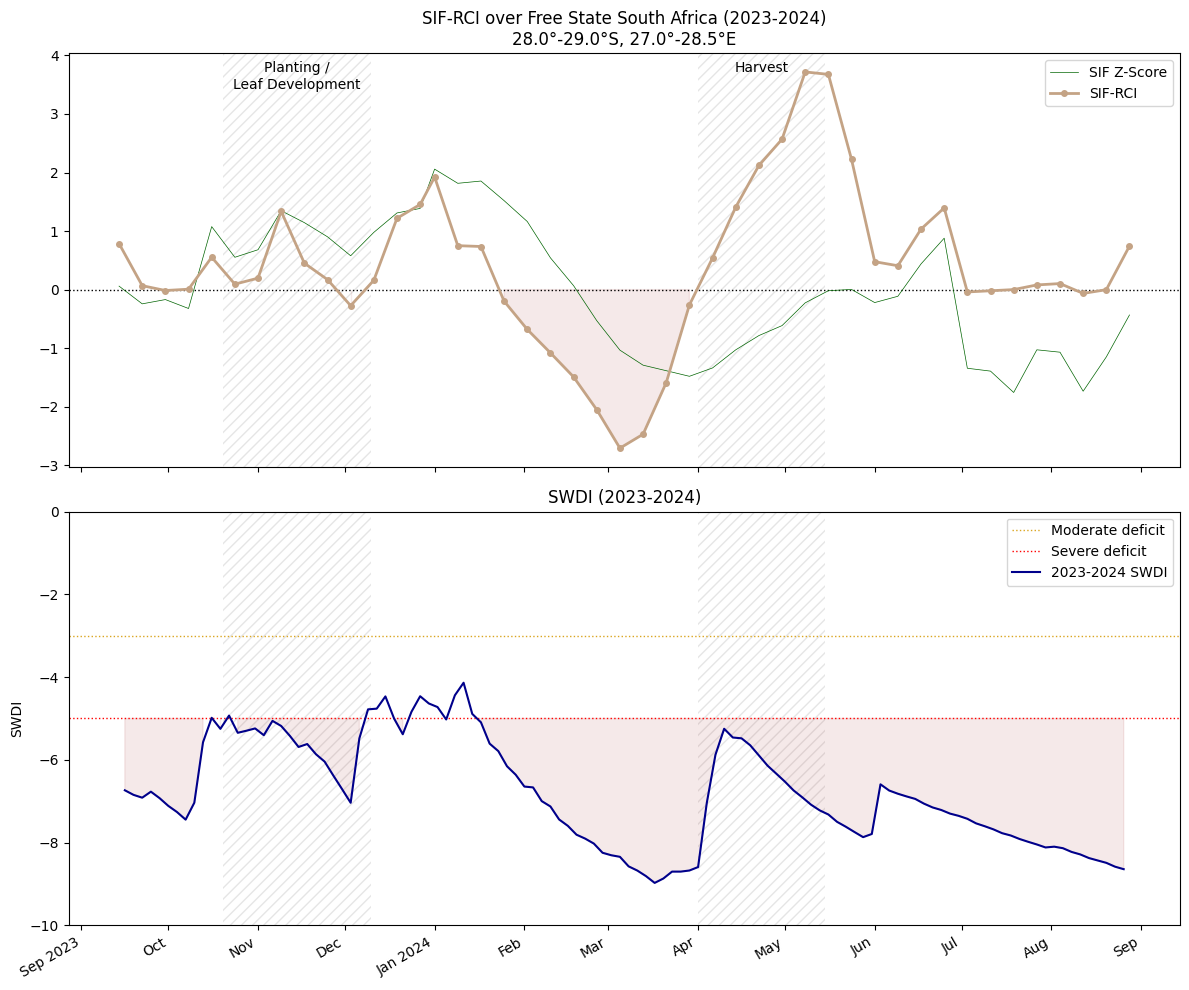

In [4]:
import csv
from datetime import datetime

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms


class MonthYearFormatter(mdates.DateFormatter):
    """Overengineered x axis tick label formatter."""

    def format_ticks(self, values):
        dates = [mdates.num2date(v) for v in values]
        labels = []
        last_year = None
        for d in dates:
            if d.year != last_year:
                labels.append(d.strftime("%b %Y"))
                last_year = d.year
            else:
                labels.append(d.strftime("%b"))
        return labels

# Read the saved CSV
plot_dates = []
plot_zscore: list[float] = []
plot_sifrci: list[float] = []
with open(sif_csv_path, newline="") as f:
    reader = csv.DictReader(f)
    for row in reader:
        pt_date = datetime.strptime(row["date"], "%Y-%m-%d") # noqa: DTZ007
        plot_dates.append(pt_date)
        if "sif_zscore" in list(row.keys()):
            plot_zscore.append(float(row["sif_zscore"]))
        else:
            plot_zscore.append(0.0)
        plot_sifrci.append(float(row["sif_rci"]))

plot2_dates = []
plot2_swdi: list[float] = []
with open(swdi_csv_path, newline="") as f:
    reader = csv.DictReader(f)
    for row in reader:
        pt_date = datetime.strptime(row["time"], "%Y-%m-%d") # noqa: DTZ007
        # Our time series of SWDI is slightly longer, so skip dates that aren't
        # in the SIF time series
        if pt_date < plot_dates[0] or pt_date > plot_dates[-1]:
            continue
        plot2_dates.append(pt_date)
        plot2_swdi.append(float(row["swdi"]))

# As before, we will highlight the period where the SIF-RCI signal
# was persistently below 0
flash_drought = [r < -0.05 for r in plot_sifrci]

# Like in the SWDI plot from the first notebook, we will highlight the period
# where the SWDI signal was persistently below -5
moderate_fd_thresh = -3
fd_thresh = -5
flash_drought_swdi = [r < fd_thresh for r in plot2_swdi]

def add_crop_calendar(ax: plt.Axes, label: bool = True) -> None:
    """Cross-hatch the usual planting and harvest windows and label them on the plot."""
    ax.axvspan(planting_start, planting_end, facecolor="none", edgecolor="grey", # type: ignore
               hatch="///", linewidth=0.0, alpha=0.2, zorder=0)
    ax.axvspan(harvest_start, harvest_end, facecolor="none", edgecolor="grey", # type: ignore
               hatch="///", linewidth=0.0, alpha=0.2, zorder=0)
    if label:
        # x in data coordinates, y in axes-fraction coordinates
        trans = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)
        ax.text(planting_start + (planting_end - planting_start) / 2, 0.98, # type: ignore
                "Planting /\nLeaf Development", transform=trans, ha="center",
                va="top", fontsize=10, color="black")
        ax.text(harvest_start + (harvest_end - harvest_start) / 2, 0.98, # type: ignore
                "Harvest", transform=trans, ha="center", va="top",
                fontsize=10, color="black")


# Plot the time series as two stacked subplots sharing the same x-axis
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True) # plt.subplots(figsize=(12, 6)) #

# Shade the crop calendar behind both subplots (labelled on the top subplot only)
add_crop_calendar(ax1)
add_crop_calendar(ax2, label=False)

# First subplot: SIF Z-score (absolute anomaly, not the "standardized anomaly" from Part 1) and SIF-RCI
ax1.axhline(0, color="black", linestyle=":", linewidth=1)
ax1.plot(plot_dates, plot_zscore, color="darkgreen", linewidth=0.5, label="SIF Z-Score")
ax1.plot(plot_dates, plot_sifrci, marker="o", color=(0.77, 0.64, 0.52), linewidth=2, markersize=4, label="SIF-RCI")
ax1.fill_between(plot_dates, plot_sifrci, 0, where=flash_drought, color="brown", alpha=0.1)
ax1.set_title(plot_title)
ax1.legend()

# Second subplot: SWDI with threshold levels
ax2.set_ylim(-10, 0)
ax2.axhline(moderate_fd_thresh, color="goldenrod", linestyle=":", linewidth=1, label="Moderate deficit")
ax2.axhline(fd_thresh, color="red", linestyle=":", linewidth=1, label="Severe deficit")
ax2.plot(plot2_dates, plot2_swdi, color="darkblue", linewidth=1.5, label=f"{plot_year_str} SWDI")
ax2.fill_between(plot2_dates, plot2_swdi, fd_thresh, where=flash_drought_swdi, color="brown", alpha=0.1)
ax2.set_ylabel("SWDI")
ax2.set_title(f"SWDI ({plot_year_str})")
ax2.legend()

ax2.xaxis.set_major_formatter(MonthYearFormatter("%b %Y"))
ax2.xaxis.set_major_locator(mdates.MonthLocator())

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### Notes on the SIF/SWDI plot

In the plot above we can look at the SIF-RCI and SWDI over the region of interest during the growing season. Unlike in Part I, where we plotted "SIF Standardized Anomaly" in addition to SIF-RCI, in this case we are looking at the Z-score of the absolute SIF anomaly. If you return to the SIF plot from Part I, you'll recall we had a plot comparing the SIF values over the growing season to the climatological mean for the same time of year. The Z-score effectively summarizes this relationship and gives us diagnostic information about the RCI metric that we are using to detect flash drought. Generally speaking, in a flash drought event the Z-score of SIF anomaly will lag the SIF-RCI by several time steps which is illustrated quite clearly in the South Africa case study here. Another reason for including the SIF Z-Score in this case is to clarify an important point about interpreting postive SIF-RCI. Since the indicator is derived from the _difference_ in SIF between time steps, positive SIF-RCI does not necessarily mean a positive SIF anomaly compared to mean. In an intuitive sense, we can think of the drought as slowing plant growth compared to what it could have been, which explains the negative values. During senescence, however, plant growth slows or stops as part of the normal crop cycle, and based on our Z-scores we can see that there is no positive anomaly in SIF. In other words, our data is not indicating a late season recovery in the crops, but rather that senescence proceeded at a normal rate compared to past years.

In the bottom subplot, SWDI values were low for most of the year. If our criteria for drought relies on values less than -5, it's worth questioning the accuracy of the RZSM estimates. To diagnose whether we "trust" these values, we can quickly examine the RZSM data in Worldview and compare previous years: https://go.nasa.gov/3V2z8Vd Looking at 2021-2024, the soil moisture over this part of South Africa was genuinely lower compared to previous years. One interesting thing to note, though, is that there is a curious discontinuity in the RZSM values between Lesotho and South Africa. The topography of Lesotho is more mountainous than the surrounding regions, and this terrain is more difficult to model in the land surface model used in the SMAP L4 data. This case study was specifically chosen to point out a shortcoming of using model-derived data, namely that the quality of the estimates will vary by region. Despite this, we will see that the combination of SWDI and SIF-RCI still provides a useful early warning of flash drought conditions.

<div style="text-align:center">
  <img style="width:960px" src="inputs/RZSM_Comparison_2021_2024.png" alt="A screenshot of NASA Worldview comparing SMAP Soil Moisture values over Lesotho and South Africa from 2021 and 2024.">
</div>

### Some practical considerations when using model-derived soil moisture estimates

While SMAP data is an incredible resource for soil moisture, there are some guidelines about where the data may be more or less reliable in applied science context like the one shown in this notebook:

* RZSM is less accurate in areas of dense canopy cover, such as broadleaf and needleleaf forests.
* Soil Moisture is more difficult to estimate over mountainous regions due to challenges of modeling small-scale terrain features. SIF is also more difficult to estimate in these regions due to the off-nadir view angle to the vegetation canopy.

Our application of RZSM data attempts to minimize these weaknesses, since most cropland lies in relatively flat regions and exhibits low canopy density (a mature corn field has a lower canopy density than a mature broadleaf forest).

## Applying Detection Rules

Now let's finally apply our rules based on the research papers we've looked at so far. Since we saved the rasters for each time step, we can apply the rule per grid cell:

### SIF-RCI
* At least 24 consecutive days (3 time steps) SIF-RCI is < -0.5

### SWDI
**Start Date**
1. SWDI decreases by at least 2 points over the preceeding 30 days (10 time steps)*
2. **Moderate FD**: SWDI < -3 for at least 12 days (4 time steps) in addition to rule 1.
3. **Severe FD**: SWDI < -5 for at least 12 days in addition to rule 1.

**End date**
1. SWDI increases by at least 2 points over the last 12 days (4 time steps)
2. SWDI > -5 for 12 days or more

*Note that this formulation is slightly different from Mohammadi and Wang, 2025 \[[4](https://doi.org/10.1175/BAMS-D-24-0143.1)\] to allow for uncertainty in $\theta_{\mathrm{FC}}$ and $\theta_{\mathrm{WP}}$. 

### Combination

* **High confidence flash drought**: both indicators flag a start date within 16 days of each other
* **Moderate confidence flash drought**: SWDI flags a start date without a corresponding SIF-RCI start date
* **Significant SIF anomaly**: If SIF-RCI flags a start date without a corresponding SWDI start date. May not be due to FD, for example floods and fires can also cause detections.
* **Slow drought transition**: No SWDI end date detected within the time range.

Optionally, we can flag FD events that occur within the growing season, which can be defined as the start of planting season to the end of the harvest season. It would be ideal to use real data to inform these dates, but this information is typically secret for large agricultural operations and difficult to obtain from smallholder farmers. Farmers don't tend to plant and harvest their crops uniformly in lock step, so the crop calendar dates are rough estimates.  

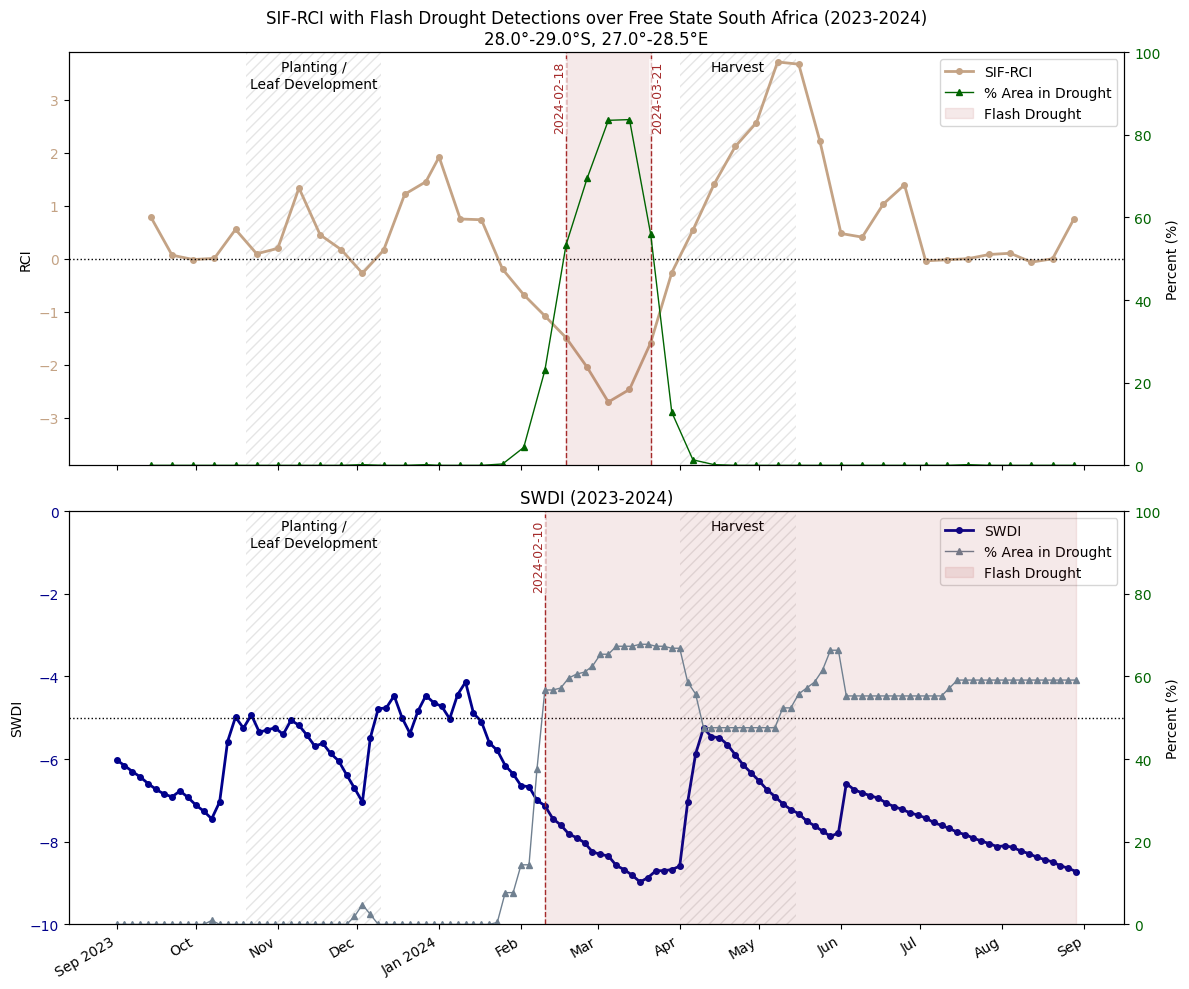

In [5]:
from analysis import detect_flash_drought_sif, detect_flash_drought_swdi

detect_flash_drought_sif(raster_dir, fd_dir, sif_csv_path)
detect_flash_drought_swdi(raster_dir, fd_dir, swdi_csv_path, abs_threshold=-5)

def add_flash_drought_markers(ax: plt.Axes, dates: list[datetime], flags: list[bool]) -> None:
    """Draw vertical dashed lines at the first and last dates below the flash drought threshold."""
    fd_dates = [d for d, flag in zip(dates, flags) if flag]
    if not fd_dates:
        return

    first_date, last_date = fd_dates[0], fd_dates[-1]
    trans = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)

    for i, d in enumerate([first_date, last_date]):
        if d == dates[-1]:
            continue
        ax.axvline(d, color="brown", linestyle="--", linewidth=1, zorder=1)
        # Alternate label alignment so start/end labels don't overlap when close together
        ha = "right" if i == 0 else "left"
        ax.text(d, 0.98, d.strftime("%Y-%m-%d"), transform=trans, ha=ha, va="top",
                fontsize=9, color="brown", rotation=90,
                bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.7, "pad": 1})
    ax.axvspan(first_date, last_date, color="brown", alpha=0.1, label="Flash Drought")


# Read the saved CSV
plot_dates = []
plot_fdperc: list[float] = []
plot_sifrci: list[float] = []
with open(sif_csv_path, newline="") as f:
    reader = csv.DictReader(f)
    for row in reader:
        pt_date = datetime.strptime(row["date"], "%Y-%m-%d") # noqa: DTZ007
        plot_dates.append(pt_date)
        plot_fdperc.append(float(row["fd_percent"]))
        plot_sifrci.append(float(row["sif_rci"]))

# Read the saved CSV
plot2_dates = []
plot2_fdperc: list[float] = []
plot2_swdi: list[float] = []
with open(swdi_csv_path, newline="") as f:
    reader = csv.DictReader(f)
    for row in reader:
        pt_date = datetime.strptime(row["time"], "%Y-%m-%d") # noqa: DTZ007
        plot2_dates.append(pt_date)
        plot2_fdperc.append(float(row["fd_percent"]))
        plot2_swdi.append(float(row["swdi"]))

fd_thresh = 50
flash_drought_sif = [r > fd_thresh for r in plot_fdperc]
flash_drought_swdi = [r2 > fd_thresh for r2 in plot2_fdperc]

# Colors for top subplot
color1 = (0.77, 0.64, 0.52)
color2 = "darkgreen"

# Colors for bottom subplot
color3 = "darkblue"
color4 = "slategray"

fig, (ax1, ax3) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
"""Subplot 1: SIF Flash Drought Detection"""
add_crop_calendar(ax1)
ax1.plot(plot_dates, plot_sifrci, marker="o", color=color1, linewidth=2, markersize=4, label="SIF-RCI")
ax1.axhline(0, color="black", linestyle=":", linewidth=1)
ax1.tick_params(axis='y', labelcolor=color1)
ylim = max([abs(r) for r in plot_sifrci])
ax1.set_ylim(-1.05 * ylim, 1.05 * ylim)
ax1.set_ylabel("RCI")
ax1.set_title(plot2_title)

ax2 = ax1.twinx()
ax2.plot(plot_dates, plot_fdperc, marker="^", color=color2, linewidth=1, markersize=4, label="% Area in Drought")
ax2.tick_params(axis="y", labelcolor=color2)
ax2.set_ylim(0, 100)
ax2.set_ylabel("Percent (%)")
add_flash_drought_markers(ax2, plot_dates, flash_drought_sif)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
legend = ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

"""Subplot 2: SWDI Flash Drought Detection"""
add_crop_calendar(ax3)
ax3.plot(plot2_dates, plot2_swdi, marker="o", color=color3, linewidth=2, markersize=4, label="SWDI")
ax3.axhline(-5, color="black", linestyle=":", linewidth=1)
ax3.tick_params(axis='y', labelcolor=color3)
ax3.set_ylim(-10, 0)
ax3.set_ylabel("SWDI")
ax3.set_title(f"SWDI ({plot_year_str})")

ax4 = ax3.twinx()
ax4.plot(plot2_dates, plot2_fdperc, marker="^", color=color4, linewidth=1, markersize=4, label="% Area in Drought")
ax4.tick_params(axis="y", labelcolor=color2)
ax4.set_ylim(0, 100)
ax4.set_ylabel("Percent (%)")
add_flash_drought_markers(ax4, plot2_dates, flash_drought_swdi)

lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax4.get_legend_handles_labels()
legend = ax3.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

ax3.xaxis.set_major_formatter(MonthYearFormatter("%b %Y"))
ax3.xaxis.set_major_locator(mdates.MonthLocator())
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


## Comparing Detection Results

The main point of comparison for the South Africa summer drought will be the Malherbe et al., 2025 paper \[[15](https://doi.org/10.1016/j.envdev.2025.101253)\], and these researchers showcased the Advanced Drought Early Warning System (ADEWS) that they developed which contains a number of different remote sensing data sources. While the authors did not identify a specific onset date for the event, they highlight period from January-March as the peak period of interest. Our data sources corroborate the obervation that there was above average rainfall in January, as SWDI reached a relative high during this period and SIF experienced a positive anomaly (and postive SIF-RCI). The SIF-RCI and SWDI signals showed over 50% of grid cells experiencing flash drought by mid-February, with both start dates occurring within 16 days of each other. The region of interest we are using roughly corresponds with the **Winburg, Senekal, and Bethlehem** magisterial districts referenced in the study, and Table 2 (see below) indicated that these areas saw **59%, 59%, and 74% of normal maize yields** in 2024 respectively. While our technique does not have a rigorous way of estimating the severity of a flash drought, the positive detection from the plot above lines up well with the timing of the drought and yield figures show that crop yields were in fact negatively impacted.

<div style="text-align:center">
  <img style="width:960px" src="inputs/Malherbe_2025_Table2.jpg" alt="A table of maize yields, Precipitation Index, and various other indicators for some magisterial districts of South Africa.">
</div>

### 2017 Northern Great Plains Case Study

Now let's take a look at the case study from Part I and apply the detection rules. To save time, this has already been done for you and the plots are saved in the inputs directory.

<div style="text-align:center">
  <img style="width:960px" src="inputs/NPlains_SIF_detection.png" alt="A plot of SIF-RCI indicating detection of flash drought in the Northern Great Plains region in 2017.">
</div>

In the SIF-RCI plot, the percent area in flash drought only just touches the 50% detection threshold on June 26, 2017. If we were to apply the same detection rule to the spatially averaged time series instead, we would consider this event to have peaked between June 26 - July 4 (or June 18 - July 12 using a SIF-RCI threshold of 0). As we saw in the map visualization, the distribution of negative SIF anomaly was more concentrated in the east of the region of interest, around the Fort Peck Reservoir area while mountainous regions in the western portion of the region exhibited positive SIF anomalies for longer. This observation is backed up by the USDM historical data that we looked at in the presentation, which showed that the eastern part of Montana entered a drought first, with the western part following later in the summer.

Now let's look at the SWDI flash drought detection plot for the region:

<div style="text-align:center">
  <img style="width:960px" src="inputs/NPlains_SWDI_detection.png" alt="A plot of SWDI indicating detection of flash drought in the Northern Great Plains region in 2017.">
</div>

The detection threshold reaches 50% on July 24th in the SWDI, which is a bit late compared to SIF-RCI data (and the true ground conditions), but there was a steady increase in grid cells exhibiting flash drought throughout the summer beginning as early as mid-May. If we wanted to modify our approach to provide a better early warning of the drought onset taking advantage of all the available information, it might be tempting to simply reduce the detection threshold in terms of % area in flash drought. A good reason _not_ to do this is that we still want to avoid declaring a flash drought pre-emptively. A quick and easy way to test the skill of a detection rule is to run the same georegion in different years that you know did not experience a flash drought. If we run our South Africa or Northern Great Plains regions in different years, we might see that small areas of these regions meet the detection rules for SIF-RCI and/or SWDI, but do not exceed 50% positive detection area overall. Because of this, an approach that seeks to characterize an early warning rather than just being sensitive to small fluctuations might consider the trajectory of the positive detections. In other words, one possible modification to the approach might be to treat 16 consecutive days (for SIF-RCI) or 12 consecutive days (for SWDI) of increasing % area in flash drought as a positive detection for the region. Using this approach, we could declare an early warning in late May or early June in the Northern Great Plains case. Our detection threshold would remain about the same (early February) in the South Africa case.


In the final section, let's look at the spatial distribution of our flash drought detection to show why we used a per-grid cell approach rather than simply applying the rules to the time series.

## Investigating the Spatial Distribution of Flash Drought

In [6]:
import functools
import os
import socketserver
import threading

from IPython.display import IFrame
from server import RangeHandler

PORT = 8000
handler = functools.partial(RangeHandler, directory=os.getcwd())

# Recreate the server if it doesn't exist yet OR if a non-range server is stale.
if not globals().get("_sif_server"):
    socketserver.TCPServer.allow_reuse_address = True
    _sif_server = socketserver.TCPServer(("127.0.0.1", PORT), handler)
    threading.Thread(target=_sif_server.serve_forever, daemon=True).start()

fd_viewer_url = f"http://127.0.0.1:{PORT}/fd_map_viewer.html?year={start.year}&doy=297&regionName={region_name}&region={west},{south},{east},{north}"
print(f"You can also open the map viewer in your browser at {fd_viewer_url}")
IFrame(src=fd_viewer_url, width=1280, height=720)

You can also open the map viewer in your browser at http://127.0.0.1:8000/fd_map_viewer.html?year=2023&doy=297&regionName=south_africa&region=27.0,-29.0,28.5,-28.0
